In [1]:
import sys
sys.path.append('/mnt/scratch/scheduler/proxy_server')
from plot_functions import *
import os

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_admission_progression(csv_path="admission_log.csv"):
    # 1. Carregar os dados
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Erro: Arquivo {csv_path} não encontrado.")
        return

    if df.empty:
        print("O arquivo CSV está vazio.")
        return

    # 2. Ordenar cronologicamente pela chegada e resetar o índice
    df = df.sort_values('arrival_time').reset_index(drop=True)

    # 3. Normalizar o tempo (Fazer o primeiro evento ser o T=0)
    start_time = df['arrival_time'].min()
    df['arrival_time_norm'] = df['arrival_time'] - start_time
    df['admit_time_norm'] = df['admit_time'] - start_time

    # 4. Configurar a figura com 2 subplots empilhados
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # ==========================================
    # Gráfico 1: Linha do Tempo (Chegada vs Admissão)
    # ==========================================
    for index, row in df.iterrows():
        # Desenha uma linha conectando a chegada e a admissão (visível se houver espera longa)
        ax1.plot([row['arrival_time_norm'], row['admit_time_norm']], [index, index], 
                 color='gray', alpha=0.5, linewidth=2)
        
        # Ponto de chegada (Vermelho)
        ax1.scatter(row['arrival_time_norm'], index, color='red', s=20, zorder=3, 
                    label='Chegada' if index == 0 else "")
        
        # Ponto de admissão (Verde)
        ax1.scatter(row['admit_time_norm'], index, color='green', s=20, zorder=3, 
                    label='Admissão' if index == 0 else "")

    ax1.set_ylabel('Índice do Programa (Ordem de Chegada)')
    ax1.set_title('Linha do Tempo: Chegada vs Admissão')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # ==========================================
    # Gráfico 2: Evolução do Tempo de Espera
    # ==========================================
    ax2.plot(df['arrival_time_norm'], df['wait_duration_s'], 
             marker='o', linestyle='-', color='purple', alpha=0.8, markersize=5)
    
    ax2.set_xlabel('Tempo desde o início do teste (segundos)')
    ax2.set_ylabel('Tempo de Espera (segundos)')
    ax2.set_title('Progressão do Tempo de Espera (Fila do Proxy)')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Ajustar layout e exibir
    plt.tight_layout()
    plt.show()

In [21]:
import json
import glob
import os
import matplotlib.pyplot as plt

def get_and_plot_completed_programs_count(directory_path):
    """
    Reads all JSON files in the specified directory matching the pattern
    'interval_rate*_run*.json', extracts the request rate and the 
    number of completely finished programs within the time window,
    and generates a plot of the results.
    
    Args:
        directory_path (str): The path to the directory containing the JSON output files.
        
    Returns:
        dict: A dictionary sorted by request rates (float), where 
              values are the counts of completed programs (int).
    """
    results = {}
    
    # Construct the search pattern based on the script's output format
    search_pattern = os.path.join(directory_path, "interval_rate*_run*.json")
    
    for filepath in glob.glob(search_pattern):
        try:
            with open(filepath, 'r') as file:
                data = json.load(file)
                
                # Extract the rate and the number of programs
                rate = data.get("full_metrics", {}).get("request_rate")
                
                # Fetching 'num_programs' from 'windowed_full_metrics' 
                completed_count = data.get("windowed_metrics", {}).get("windowed_full_metrics", {}).get("num_programs", 0)
                
                if rate is not None:
                    results[rate] = completed_count
                    
        except Exception as e:
            print(f"Error reading {filepath}: {e}")
            
    # Sort the dictionary by its keys (request rates) before plotting
    sorted_results = dict(sorted(results.items()))
    
    # --- Plotting Logic ---
    if sorted_results:
        # Extract X and Y values
        rates = list(sorted_results.keys())
        counts = list(sorted_results.values())
        
        # Create the plot
        plt.figure(figsize=(10, 6))
        plt.plot(rates, counts, marker='o', linestyle='-', color='b')
        
        # Add labels, title, and formatting
        plt.title('Completed Programs vs. Request Rate', fontsize=14)
        plt.xlabel('Request Rate', fontsize=12)
        plt.ylabel('Number of Completed Programs', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # Display the plot
        plt.tight_layout()
        plt.show()
    else:
        print("No valid data found to plot.")
        
    return sorted_results

In [3]:
import json
import glob
import os

def get_completed_programs_count(directory_path):
    """
    Reads all JSON files in the specified directory matching the pattern
    'interval_rate*_run*.json', and extracts the request rate and the 
    number of completely finished programs within the time window.
    
    Args:
        directory_path (str): The path to the directory containing the JSON output files.
        
    Returns:
        dict: A dictionary sorted by request rates (float), where 
              values are the counts of completed programs (int).
    """
    results = {}
    
    # Construct the search pattern based on the script's output format
    search_pattern = os.path.join(directory_path, "interval_rate*_run*.json")
    
    for filepath in glob.glob(search_pattern):
        try:
            with open(filepath, 'r') as file:
                data = json.load(file)
                
                # Extract the rate and the number of programs
                rate = data.get("full_metrics", {}).get("request_rate")
                
                # Fetching 'num_programs' from 'windowed_full_metrics' 
                completed_count = data.get("windowed_metrics", {}).get("windowed_full_metrics", {}).get("num_programs", 0)
                
                if rate is not None:
                    results[rate] = completed_count
                    
        except Exception as e:
            print(f"Error reading {filepath}: {e}")
            
    # Sort the dictionary by its keys (request rates) before returning
    sorted_results = dict(sorted(results.items()))
    
    return sorted_results

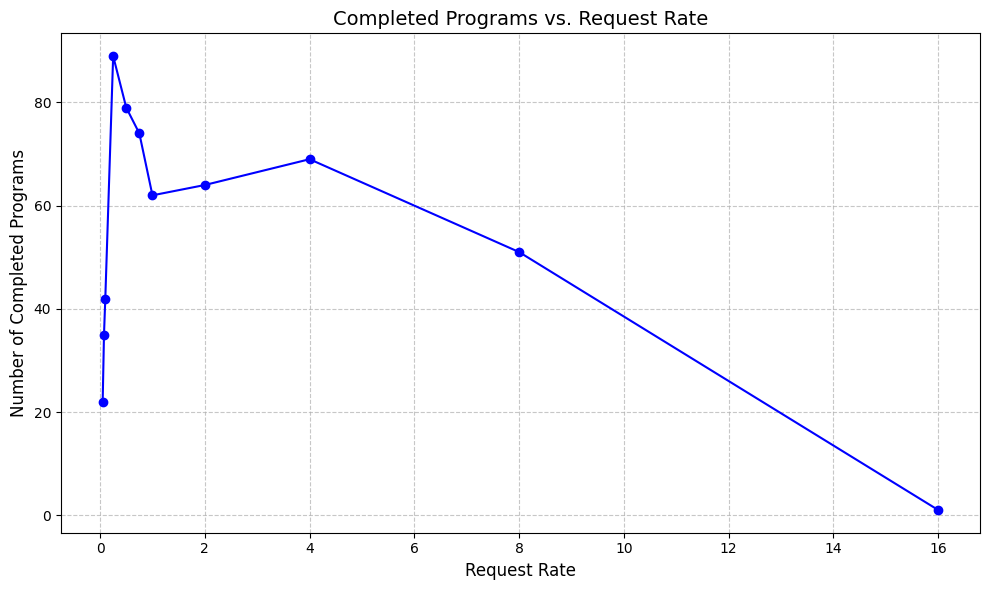

{0.05: 22,
 0.075: 35,
 0.1: 42,
 0.25: 89,
 0.5: 79,
 0.75: 74,
 1.0: 62,
 2.0: 64,
 4.0: 69,
 8.0: 51,
 16.0: 1}

In [23]:
get_and_plot_completed_programs_count("st50_dur500_win10_thr50_cd05")

In [4]:
get_completed_programs_count("interval_250_correct")

{0.05: 9,
 0.075: 15,
 0.1: 20,
 0.25: 34,
 0.5: 0,
 1.0: 0,
 4.0: 0,
 8.0: 0,
 16.0: 0}

In [5]:
get_completed_programs_count("interval_250_sleep")

{0.05: 7,
 0.075: 9,
 0.1: 6,
 0.25: 21,
 0.5: 8,
 0.75: 1,
 1.0: 0,
 2.0: 0,
 4.0: 0,
 8.0: 0,
 16.0: 0}

In [6]:
#start 0
get_completed_programs_count("st0_dur250_win10_thr50_cd05")

{0.05: 9,
 0.075: 15,
 0.1: 18,
 0.25: 34,
 0.5: 34,
 0.75: 46,
 1.0: 43,
 2.0: 45,
 8.0: 37,
 16.0: 1}

In [7]:
#default
get_completed_programs_count("st50_dur250_win10_thr50_cd05")

{0.05: 10,
 0.075: 14,
 0.1: 20,
 0.25: 31,
 0.5: 25,
 0.75: 14,
 1.0: 6,
 2.0: 0,
 4.0: 0,
 8.0: 8,
 16.0: 0}

In [8]:
#duration 100
get_completed_programs_count("st50_dur100_win10_thr50_cd05")

{0.05: 2,
 0.075: 4,
 0.1: 4,
 0.25: 2,
 0.5: 1,
 0.75: 0,
 1.0: 0,
 2.0: 0,
 4.0: 0,
 8.0: 0,
 16.0: 0}

In [9]:
#duration 500
get_completed_programs_count("st50_dur500_win10_thr50_cd05")

{0.05: 22,
 0.075: 35,
 0.1: 42,
 0.25: 89,
 0.5: 79,
 0.75: 74,
 1.0: 62,
 2.0: 64,
 4.0: 69,
 8.0: 51,
 16.0: 1}

In [10]:
#threshold 75
get_completed_programs_count("st50_dur250_win10_thr75_cd05")

{0.05: 10,
 0.075: 14,
 0.1: 19,
 0.25: 33,
 0.5: 24,
 0.75: 10,
 1.0: 3,
 2.0: 3,
 4.0: 2,
 16.0: 0}

In [11]:
#threshold 90
get_completed_programs_count("st50_dur250_win10_thr90_cd05")

{0.05: 10,
 0.075: 13,
 0.1: 18,
 0.25: 33,
 0.5: 3,
 0.75: 3,
 1.0: 1,
 2.0: 0,
 4.0: 0,
 8.0: 0,
 16.0: 0}

In [12]:
get_completed_programs_count("st50_dur250_win30_thr50_cd05")

{0.05: 10,
 0.075: 14,
 0.1: 20,
 0.25: 32,
 0.5: 21,
 0.75: 13,
 1.0: 8,
 2.0: 0,
 4.0: 0,
 8.0: 0,
 16.0: 0}

In [24]:
get_completed_programs_count("st50_dur250_win60_thr50_cd05")

{0.05: 10,
 0.075: 13,
 0.1: 18,
 0.25: 34,
 0.5: 30,
 0.75: 13,
 2.0: 0,
 4.0: 0,
 8.0: 0,
 16.0: 0}

In [14]:
plot_admission_progression(csv_path="teste10/interval_rate4_run1_admission_log.csv")

Erro: Arquivo teste10/interval_rate4_run1_admission_log.csv não encontrado.


In [15]:
get_completed_programs_count("interval_250_admission_control")

Error reading interval_250_admission_control/interval_rate8_run1.json: Expecting value: line 21071 column 25 (char 763802)


{0.05: 9,
 0.075: 14,
 0.1: 20,
 0.25: 33,
 0.5: 1,
 0.75: 2,
 1.0: 0,
 2.0: 0,
 4.0: 0}

In [ ]:
PATH="st0_dur250_win10_thr50_cd05"

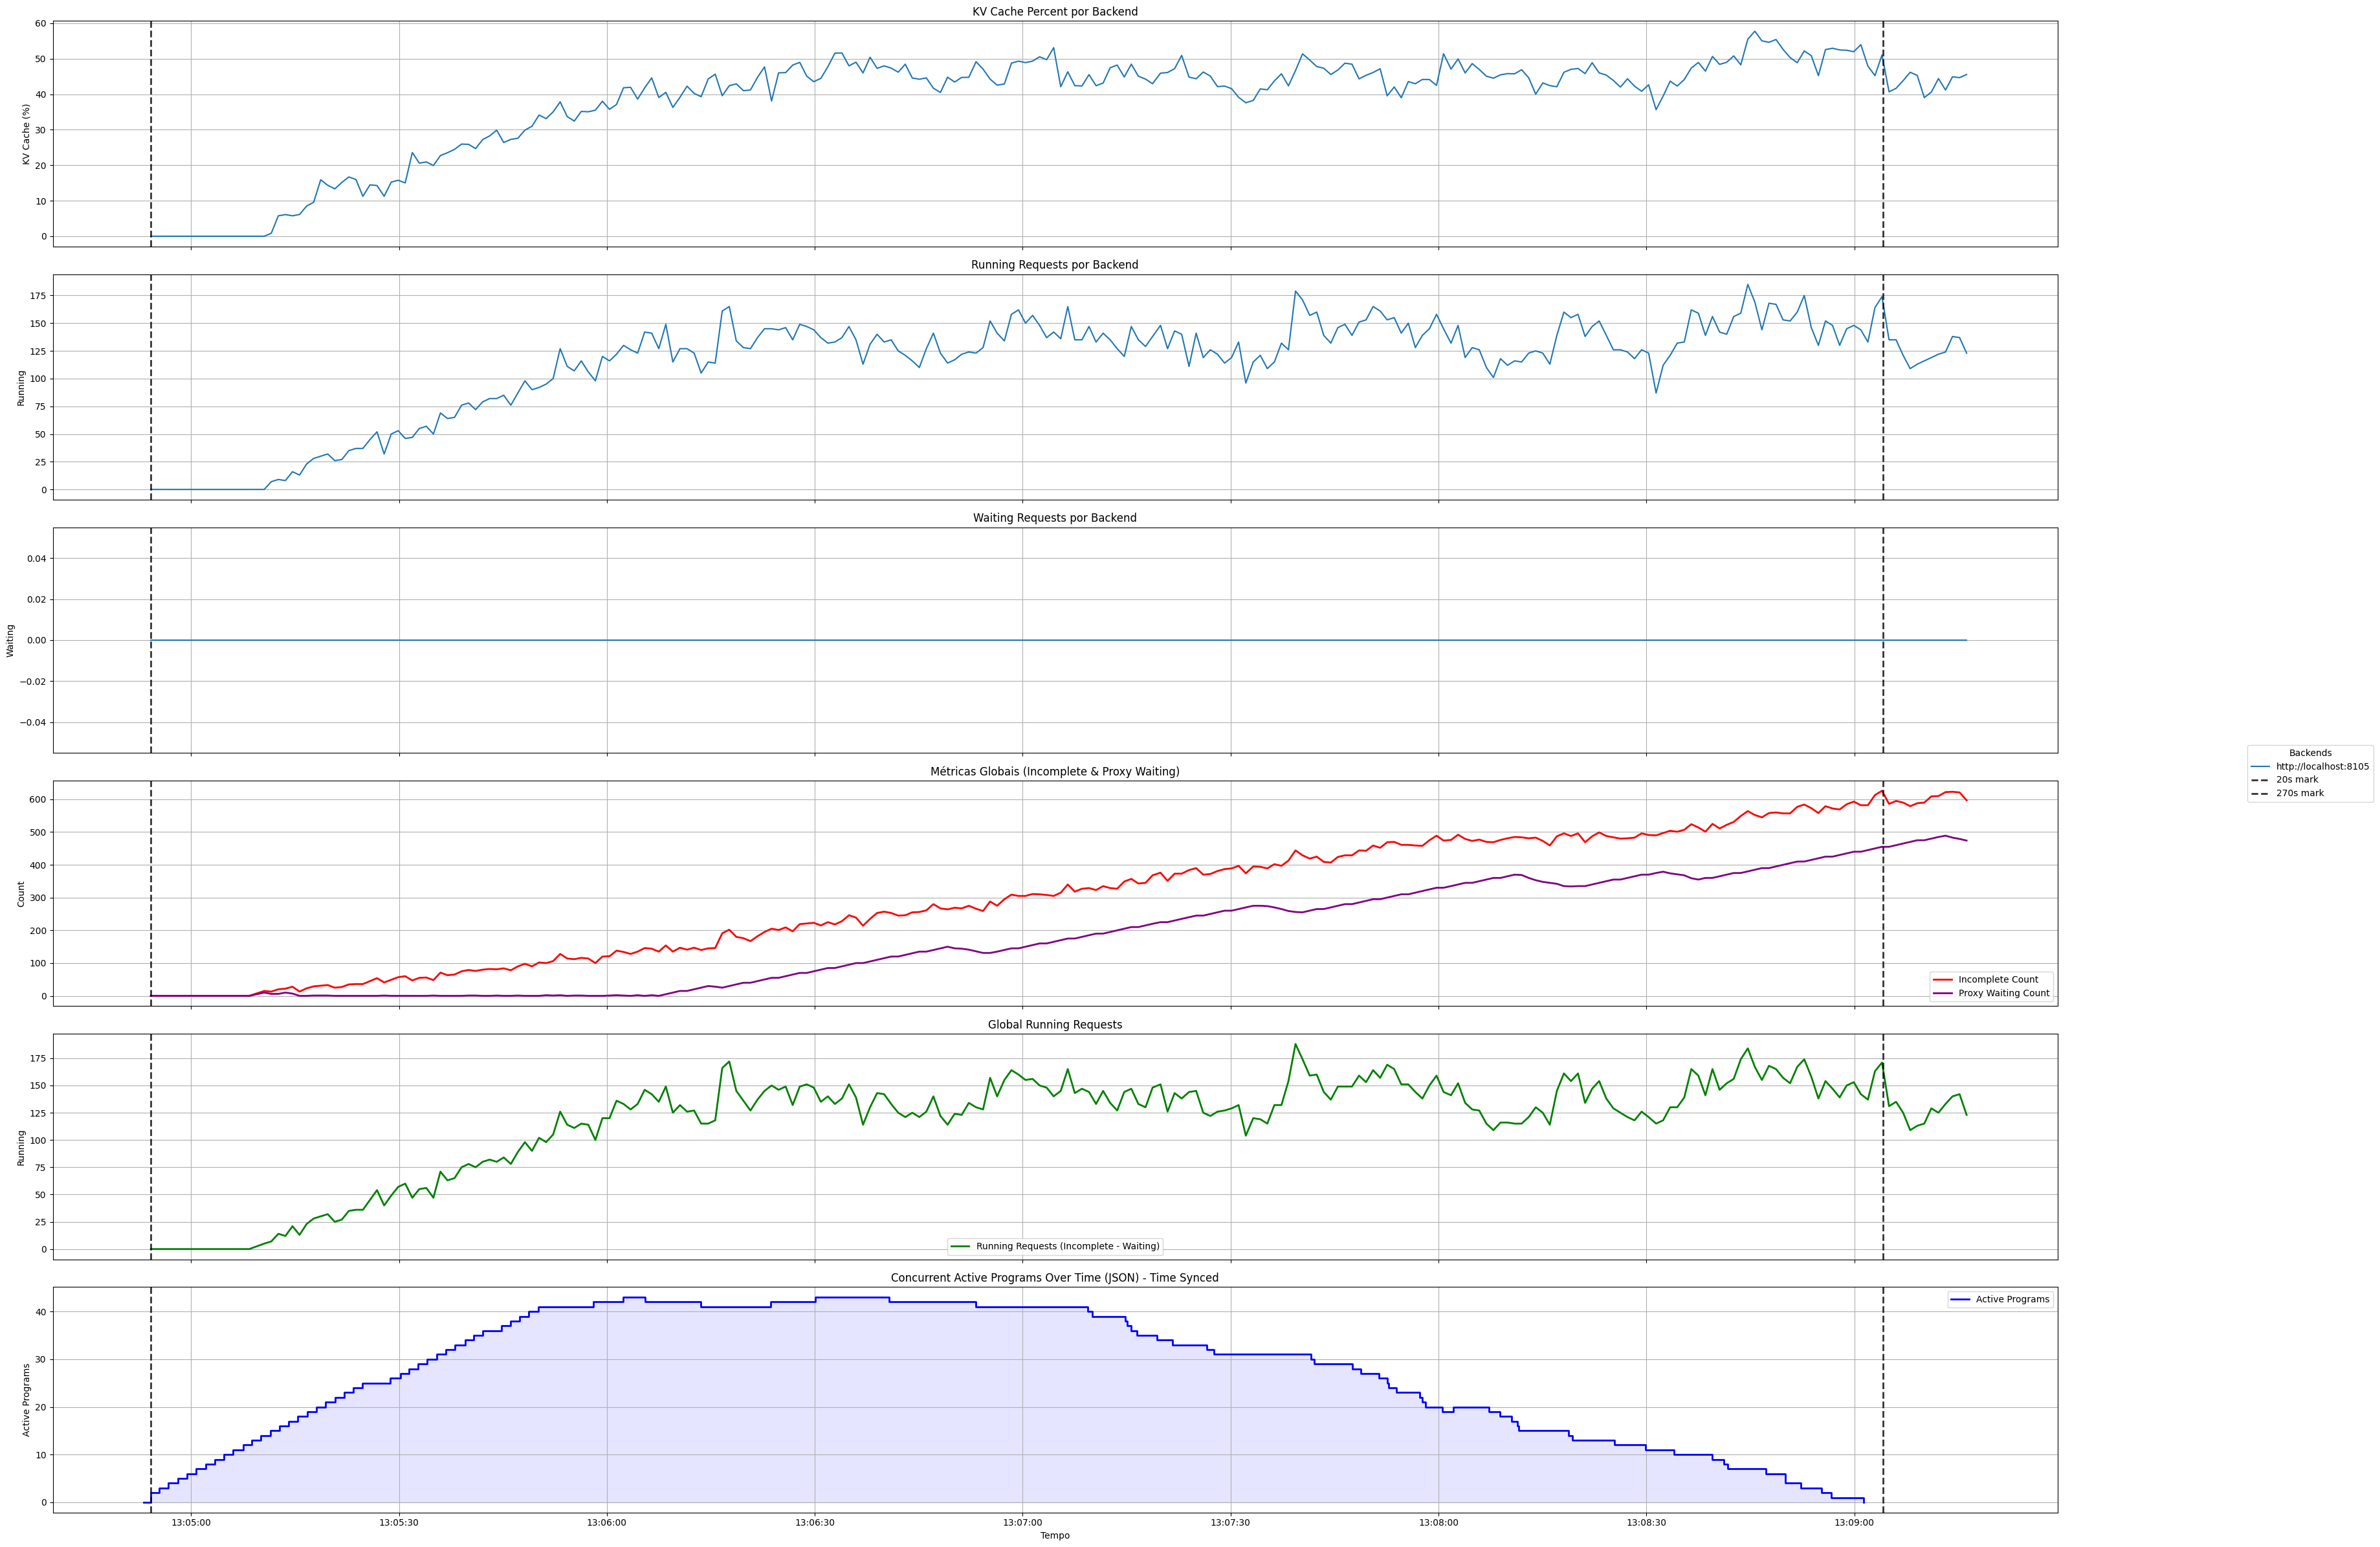

In [17]:
plot_metrics(f"{PATH}/interval_rate0.75_run1_kv_cache.csv", show_engine_load=False)

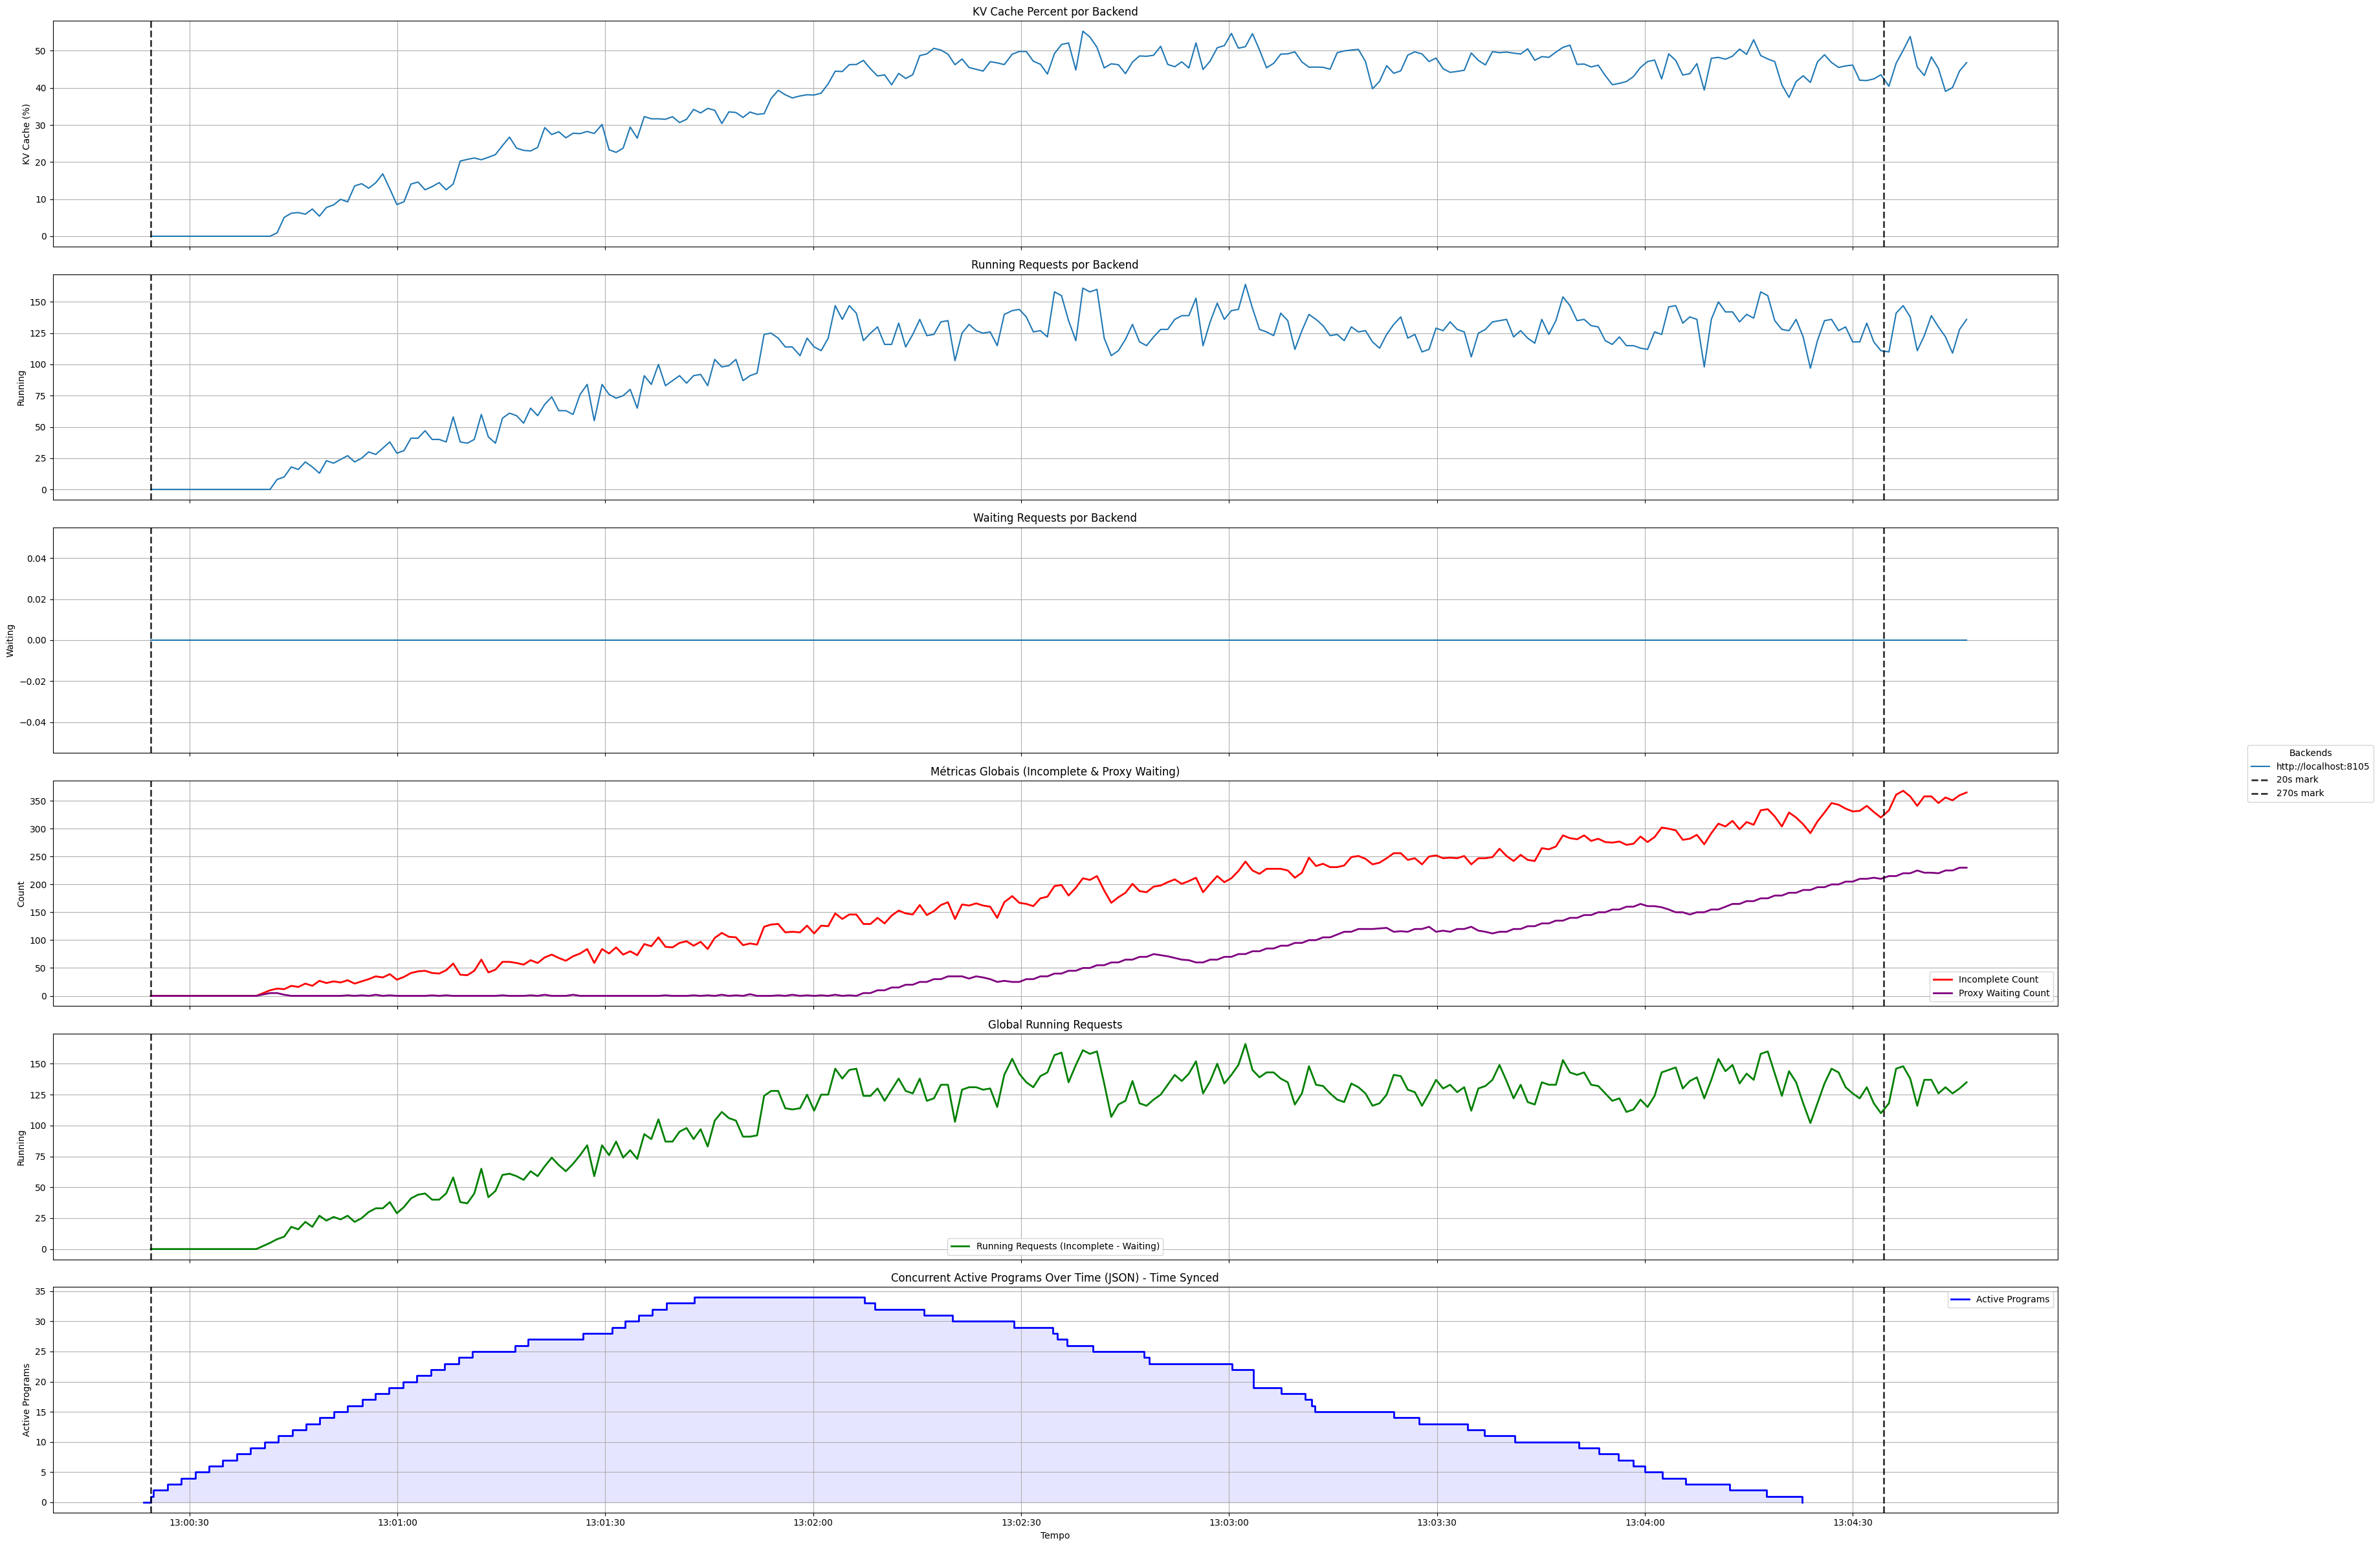

In [18]:
plot_metrics(f"{PATH}/interval_rate0.5_run1_kv_cache.csv", show_engine_load=False)

In [19]:
plot_metrics(f"{PATH}/interval_rate1_run1_kv_cache.csv", show_engine_load=False)

FileNotFoundError: [Errno 2] No such file or directory: 'st0_dur250_win10_thr50_cd05/interval_rate1_run1_kv_cache.csv'

In [ ]:
plot_metrics(f"{PATH}/interval_rate4_run1_kv_cache.csv", show_engine_load=False)

In [ ]:
plot_metrics(f"{PATH}/interval_rate8_run1_kv_cache.csv", show_engine_load=False)

In [ ]:
plot_metrics(f"{PATH}/interval_rate16_run1_kv_cache.csv", show_engine_load=False)